In [1]:
import seaborn as sns
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

from outlier_detection import isolation_forest_outliers

from feature_selection import k_best_f_regression
from feature_selection import feature_importance_selection_keep_n

from main import load_data
from imputation import transform_df

folder = 'data'
X_train_df, y_train_df, X_predict_df = load_data(
    f'{folder}/X_train.csv', f'{folder}/y_train.csv', f'{folder}/X_test.csv')


In [2]:
#scaling &imputation

#scaling
scaler = StandardScaler()
scaler.fit(X_train_df)
X_train_df = transform_df(X_train_df, scaler)

# #imputation
imputer = KNNImputer(n_neighbors=5)
imputer.fit(X_train_df)
X_train_df = transform_df(X_train_df, imputer)


In [3]:
#remove outliers
X_train_df, y_train_df = isolation_forest_outliers(X_train_df, y_train_df, 0.1)

contamination:0.1; Number of outliers = 122


In [4]:
#feature selection
X_train_df, selector = feature_importance_selection_keep_n(X_train_df, y_train_df, 10)

c:\Users\domil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [5]:
X_train_df

,x115,x133,x242,x325,x334,x458,x507,x641,x671,x742
id,,,,,,,,,,
0,1.165688,-0.242720,0.543254,-0.279288,-0.222804,1.440872,-0.152354,0.253876,0.235730,-0.368048
1,-0.490523,0.892194,0.741784,1.611872,0.973264,-0.251563,-1.179347,-0.688871,1.126323,3.693261
2,-0.452960,0.425399,-0.822577,-0.698224,-0.815280,-1.037505,-0.690027,-0.932702,-0.378671,-0.492389
3,1.109370,-2.927806,-2.940870,-3.106422,-2.952175,0.341666,1.173200,0.483339,-3.372023,-0.897638
4,0.195010,0.273856,1.286193,-0.706790,0.304487,1.078820,0.419837,0.209747,0.827140,-0.283890
...,...,...,...,...,...,...,...,...,...,...
1207,-0.479157,0.700920,-0.265184,0.899505,0.990357,0.021412,0.058777,-0.277161,1.546386,0.551094
1208,-0.152594,-0.162289,0.576074,0.203471,0.089455,0.717167,1.354977,0.762952,0.513203,-0.213882
1209,-0.412465,0.416114,-0.419288,0.825372,0.525979,-1.627203,-0.506723,-0.185467,0.315020,2.812776


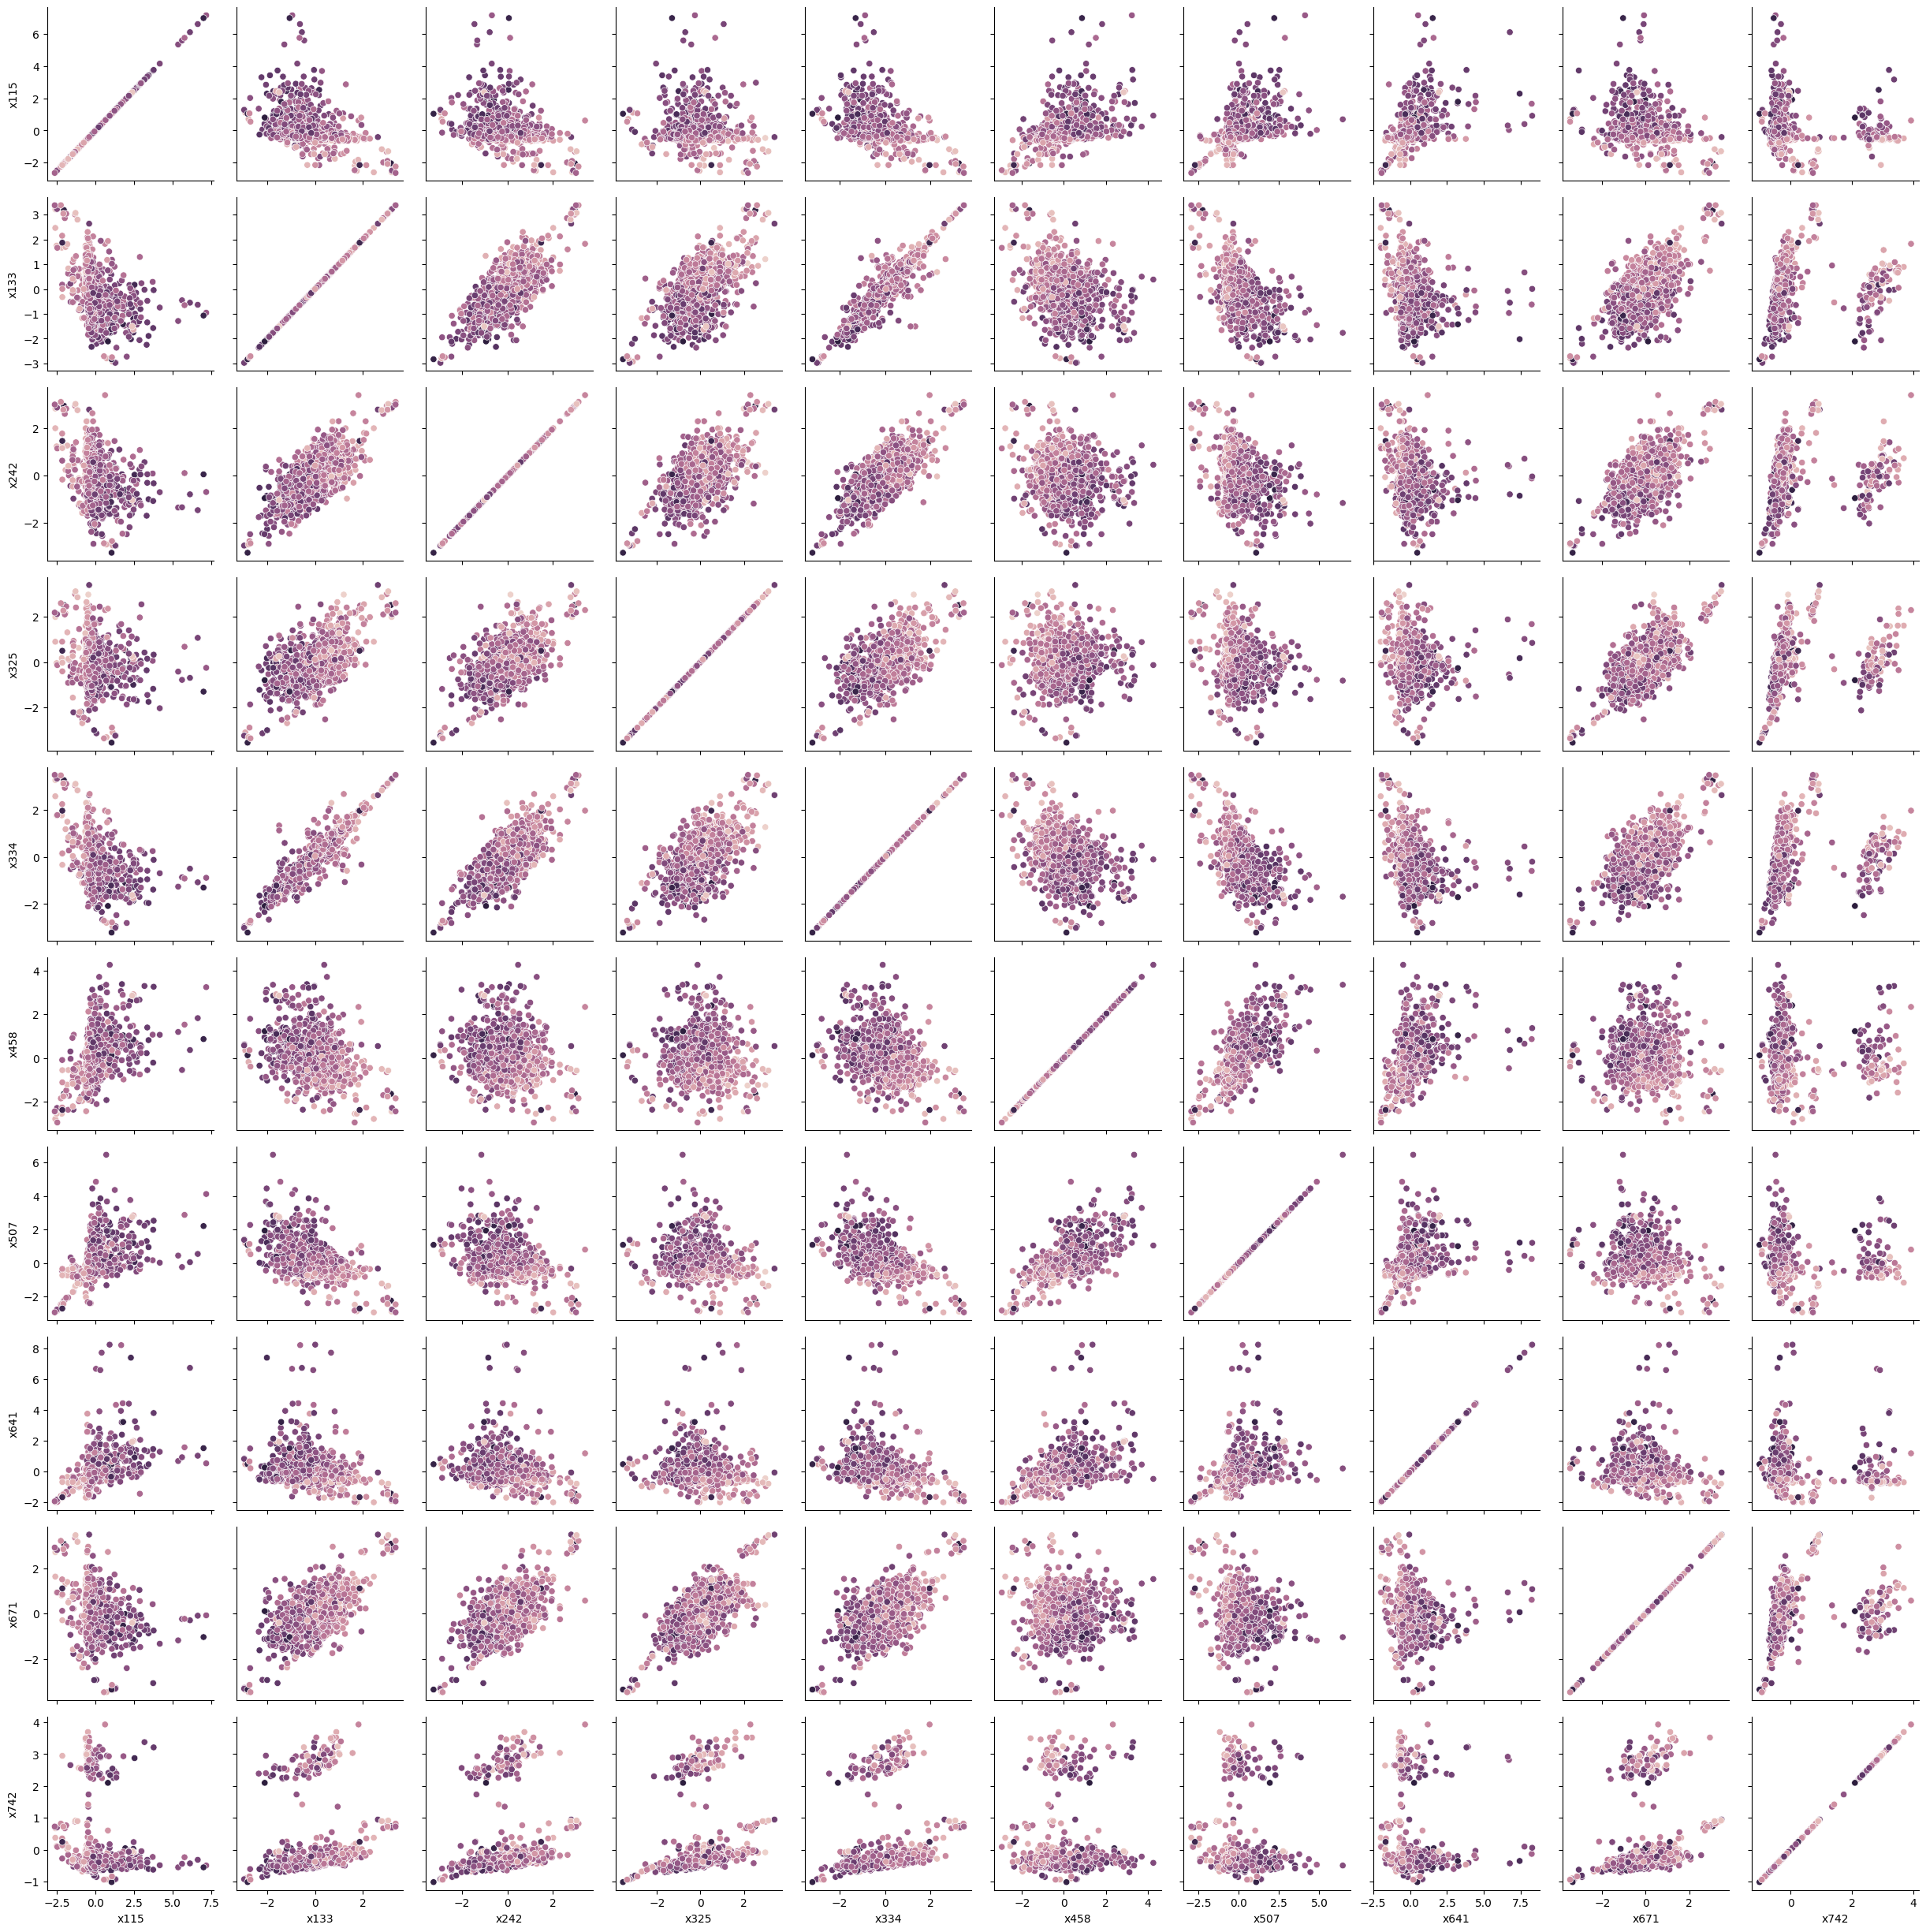

In [6]:
g = sns.PairGrid(pd.concat([X_train_df, y_train_df], axis=1), hue='y')
g.map(sns.scatterplot)

<Axes: ylabel='Frequency'>

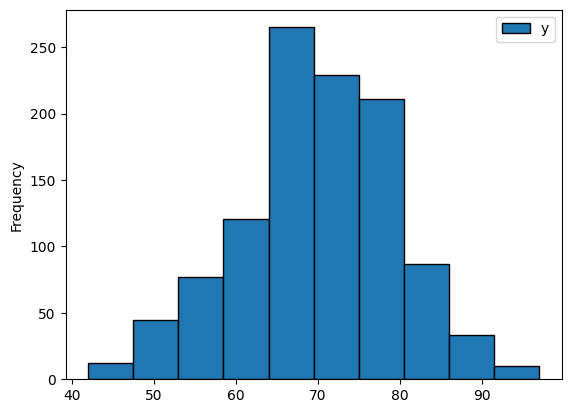

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a histogram of the Series
y_train_df.plot(kind='hist', edgecolor='black', bins=10)

In [11]:
from sklearn.model_selection import GridSearchCV

rf_reg = RandomForestRegressor(n_jobs=6)

parameters = {
    'n_estimators': [600, 700, 800, 900],
    'max_depth': [None, 10, 12, 14], 
    'min_samples_split': [4, 5, 6],
    'max_features': [2, 4, 6, 8, 10],
}

gs = GridSearchCV(rf_reg, parameters, verbose=1)
gs.fit(X_train_df, y_train_df)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


c:\Users\domil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\domil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\domil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\domil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1152: DataConvers

GridSearchCV(estimator=RandomForestRegressor(n_jobs=6),
             param_grid={'max_depth': [None, 10, 12, 14],
                         'max_features': [2, 4, 6, 8, 10],
                         'min_samples_split': [4, 5, 6],
                         'n_estimators': [600, 700, 800, 900]},
             verbose=1)

In [9]:
from sklearn.metrics import r2_score

estimator = gs.best_estimator_
r2_score(y_train_df, estimator.predict(X_train_df))

0.8559262934574284

In [12]:
from sklearn.metrics import r2_score

estimator = gs.best_estimator_
r2_score(y_train_df, estimator.predict(X_train_df))

0.8708675706653597

In [10]:
gs.best_params_, gs.best_score_

({'max_depth': 12,
  'max_features': 2,
  'min_samples_split': 5,
  'n_estimators': 400},
 0.4816360631249036)

In [13]:
gs.best_params_, gs.best_score_

({'max_depth': 14,
  'max_features': 2,
  'min_samples_split': 5,
  'n_estimators': 900},
 0.4822067885840612)

In [3]:
gs.best_params_,  gs.best_score_

({'max_depth': 12, 'n_estimators': 175}, 0.501476958774169)

In [3]:
gs.best_params_,  gs.best_score_

({'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 350},
 0.4981851642931111)

In [14]:
X_predict_df

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x822,x823,x824,x825,x826,x827,x828,x829,x830,x831
id,,,,,,,,,,,,,,,,,,,,,
0,14655.540585,9917.388635,3368.691863,104367.124458,104.132894,95.412138,9222.286185,NaN,10054.751221,8.735165,...,9153.072463,12039.009308,714.005017,105.651509,103.574436,2628.082823,2.766271,1553.285942,1037.998392,9762.400011
1,13875.822363,9955.163751,3118.195658,103577.269601,103.290975,86.916779,9625.725002,10592.011548,10234.818476,10.853218,...,9915.292110,12579.041315,695.070183,106.900274,105.241730,2388.096545,NaN,1386.519117,1088.519466,11748.788738
2,14807.162495,10682.476988,3335.687716,106647.642610,109.481676,86.476353,9128.693785,10880.979240,10485.268796,10.294348,...,9733.845509,11009.075093,663.093857,105.541065,101.875603,2097.004365,2.362592,1204.527342,1067.697534,12487.217965
3,12253.667985,9001.609788,2631.482012,91105.570966,108.741037,84.542046,9765.458299,10953.438053,10190.986014,9.159968,...,11204.016625,9395.016940,656.018142,104.816602,107.213434,2035.045976,3.052844,794.341243,NaN,7931.828963
4,18925.988003,12161.366373,3724.006508,110262.565336,102.085795,107.920270,9494.243179,10684.550944,10074.187696,10.372417,...,11093.701929,13876.039832,964.037692,104.557952,109.185247,2971.082813,2.571392,1207.265749,1013.661254,8241.962297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,12915.908280,10313.516386,3339.024965,NaN,109.580429,101.020255,10481.166660,10032.785913,10319.731898,9.418286,...,9509.882736,11579.025189,689.031306,105.024718,104.720490,1783.051318,2.312930,1582.022774,1013.001968,NaN
772,14866.856670,8940.451109,3252.927684,113514.393499,101.136893,77.681767,9792.678721,10396.746372,10431.947890,9.712914,...,9661.110937,12576.035460,684.081342,NaN,105.099666,2073.098397,NaN,1442.542973,NaN,9190.490042
773,16027.098672,NaN,3235.812109,115373.852361,106.789855,87.083643,10356.795371,10422.221126,10252.846021,10.437340,...,10250.308929,14438.049119,882.011329,103.824762,101.585975,2913.049944,2.756702,1577.603214,1005.415175,NaN


In [16]:
rf_reg  = gs.best_estimator_

X_predict_df = transform_df(X_predict_df, scaler)
X_predict_df = transform_df(X_predict_df, imputer)
X_predict_df = selector(X_predict_df)

array([60.95706199, 78.01391286, 73.32455761, 71.48221531, 75.64882755,
       57.03689633, 68.98539797, 72.39468667, 69.61215413, 65.06607489,
       74.09059765, 75.59034886, 60.8203919 , 68.27798504, 77.41031675,
       70.36684373, 71.79228008, 70.06564299, 64.12415073, 63.6832256 ,
       62.74835612, 59.82201469, 77.25222094, 78.47835571, 59.44707619,
       72.58723311, 77.87833095, 73.98252739, 67.28022098, 67.2173307 ,
       62.56304111, 75.97287188, 71.07406564, 66.04669909, 67.4126157 ,
       60.42746534, 68.93199121, 77.06641142, 69.07806237, 64.72651957,
       70.13768319, 68.94279868, 71.96403888, 71.09004508, 59.61942768,
       76.5451277 , 65.98242606, 75.46628977, 74.81656246, 77.39230987,
       78.12762839, 62.03137812, 75.3950122 , 74.38138008, 75.07142824,
       79.30436948, 72.63100741, 72.1567262 , 67.40411326, 70.78802049,
       73.13059303, 70.92033321, 68.3693743 , 74.40485304, 75.71049548,
       67.56872187, 73.07856741, 61.36984288, 76.85523319, 78.92

In [20]:
prediction = rf_reg.predict(X_predict_df)
y_predicted_df = pd.DataFrame({
    'id': X_predict_df.index.copy(),
    'y': prediction
})

y_predicted_df.to_csv('data/Y_test_domi.csv', index=False)

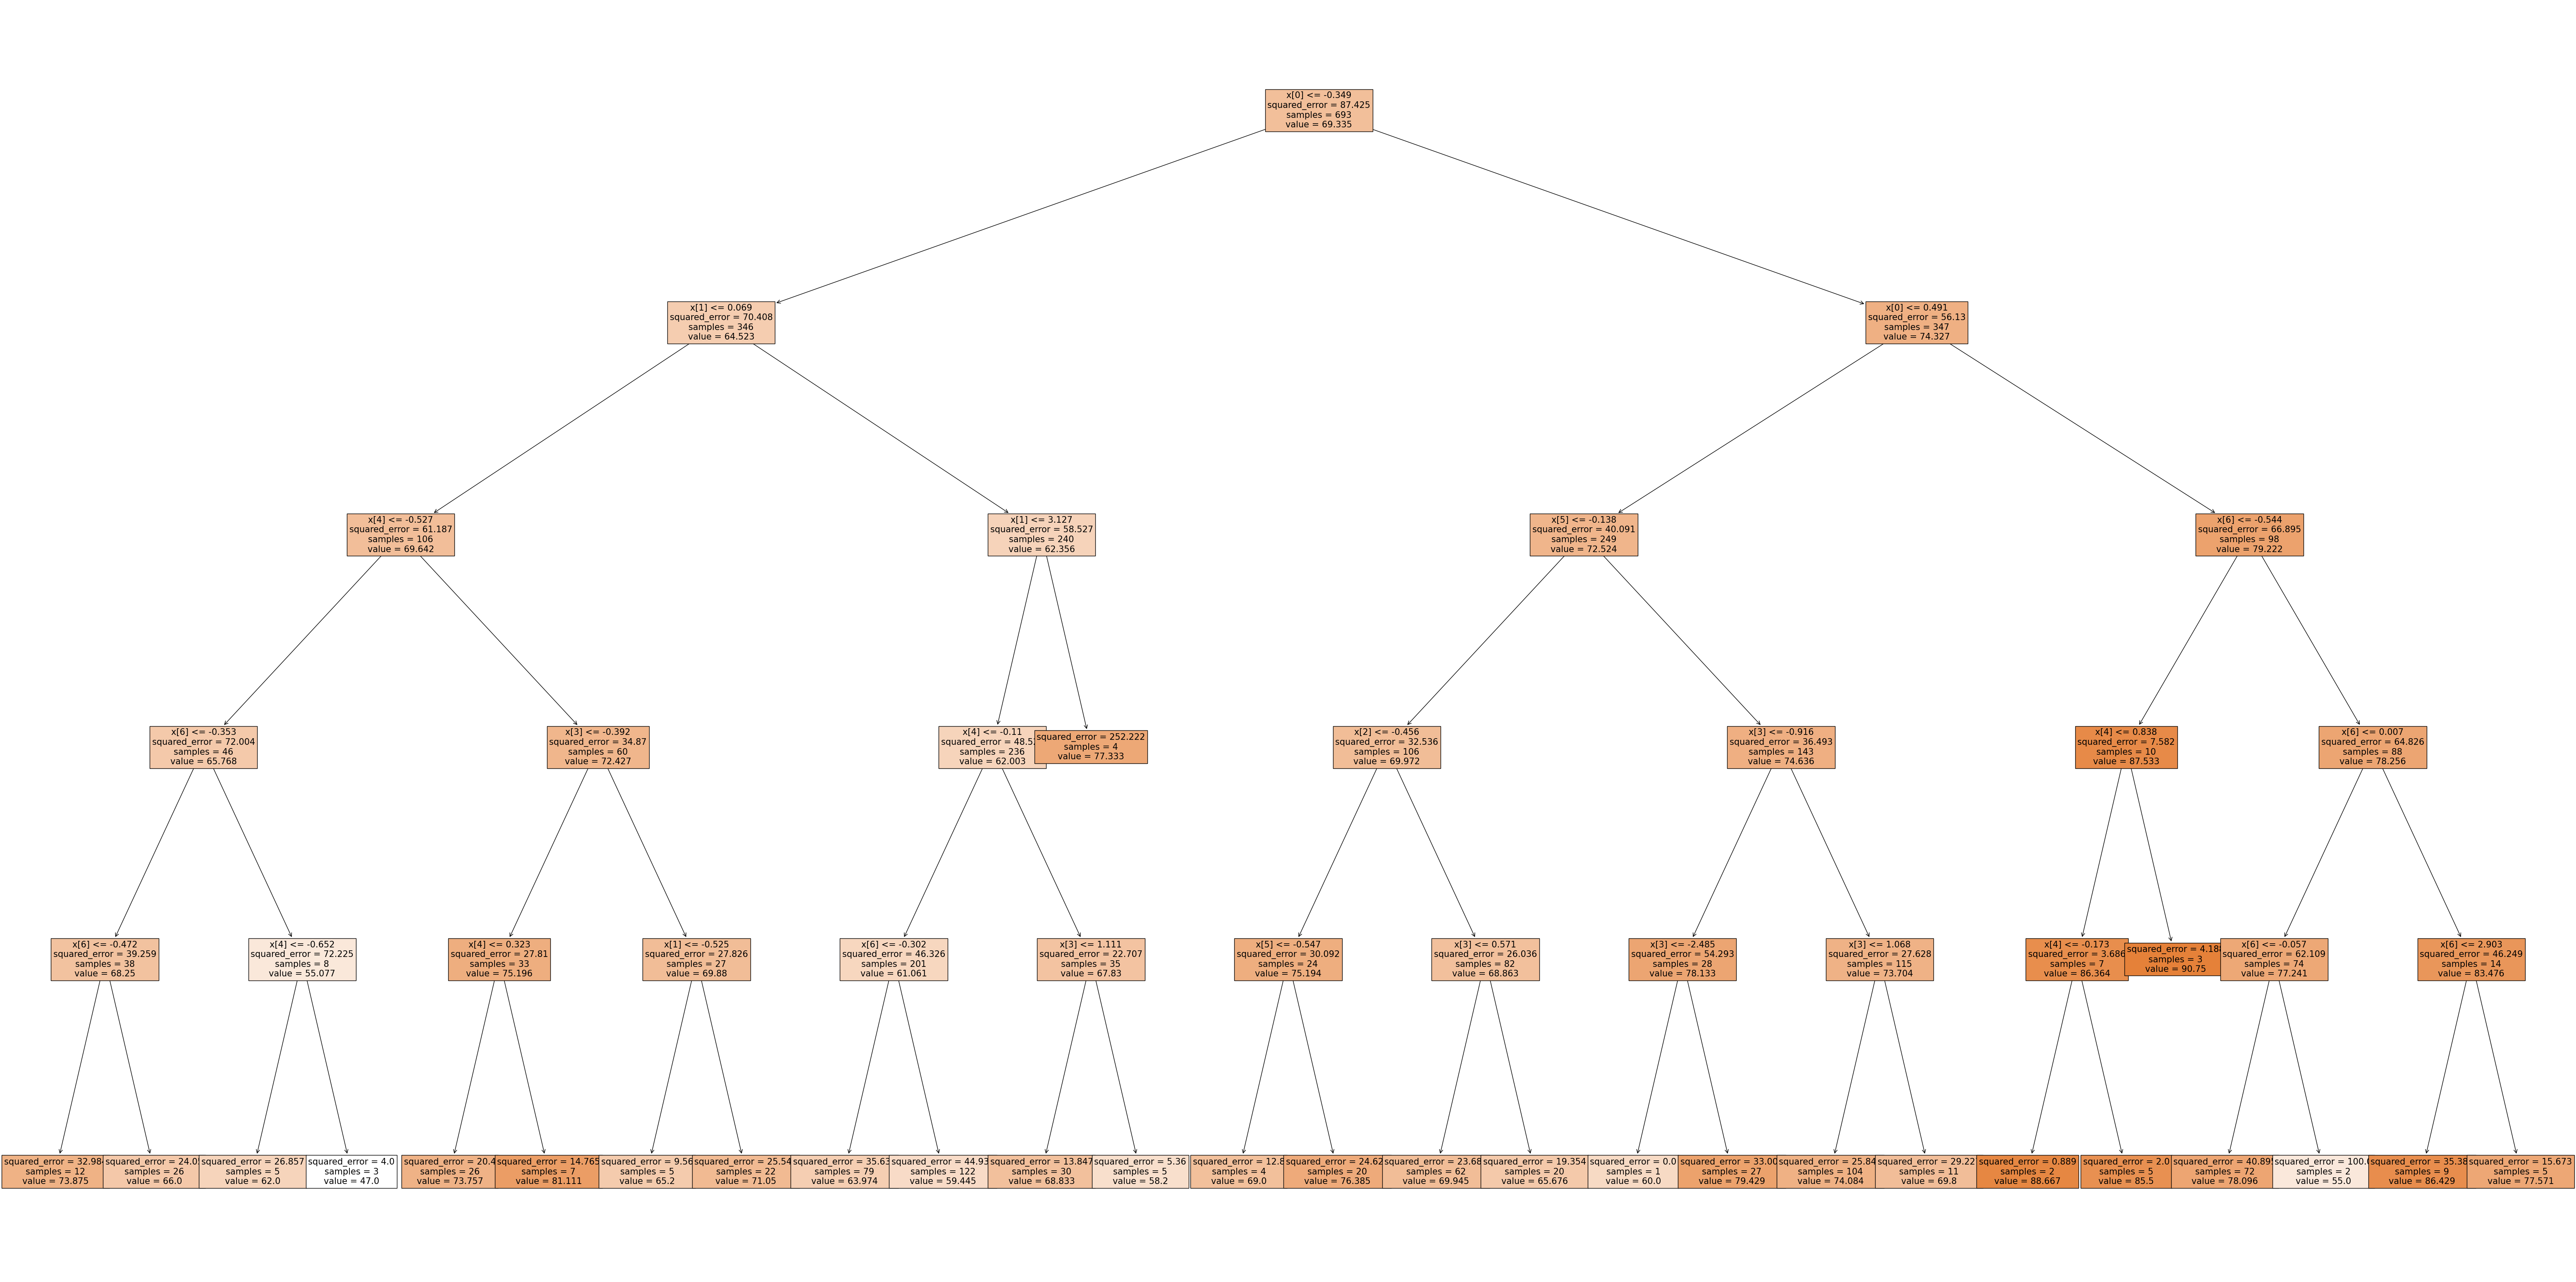

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = gs.best_estimator_.estimators_[0]

plt.figure(figsize=(80, 40))
plot_tree(tree, filled=True, fontsize=15)
plt.show()

In [ ]:
X_predict_df = scaler.transform(X_predict_df)
X_predict_df = imputer.transform(X_predict_df)
X_predict_df = selector(X_predict_df)

